# Notebook 07 — SCTS-v2 Trust Score

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Stage:** 7 of 10

## What is SCTS-v2

SHAP-Calibrated Trust Score, version 2. A per-alert score in [0, 100] that combines three orthogonal signals:

| Component | What it measures | Source |
|---|---|---|
| **c₁ — Calibration confidence** | How well-calibrated is the predicted-class probability? | Notebook 03 v2 calibrated probabilities |
| **c₂ — Explanation stability** | How robust is the SHAP top-10 under adversarial perturbation? | Notebook 05 perturbed SHAP arrays |
| **c₃ — Conformal coverage** | Does the prediction sit inside the conformal prediction set? | Computed here (split-conformal) |

## Combination formula

$$\text{SCTS-v2} = (c_1 \cdot c_2 \cdot c_3)^{1/3} \cdot 100$$

**Geometric mean rationale:** If any one component is weak, the trust score reflects that. An arithmetic mean would let a strong calibration mask a fragile explanation; geometric mean penalises asymmetry. SCTS-v2 → 0 if any component → 0; SCTS-v2 → 100 only if all three are strong.

## Methodology choices

- **Stability component**: per-sample Jaccard top-10 between original and *worst-case* perturbed SHAP (worst across Gaussian/FGSM/PGD). Conservative.
- **Conformal**: split-conformal at α ∈ {0.05, 0.10, 0.20}. Calibration half (from Notebook 03) fits the conformal threshold; eval half is scored.
- **Scope**: only the 1,633 samples in the stability subset (Notebook 05's intersection of eval half × stratified subset). These are the samples where we have c₁, c₂, c₃ all computed.
- **All 6 canonical models**.

## Output

```
results/scts/
├── scts_per_sample.npz            # SCTS-v2 array per (model, alpha)
├── components_per_sample.npz       # c1, c2, c3 arrays per model
├── scts_summary.csv                # per-model summary (mean, by class)
└── scts_alpha_sensitivity.csv      # alpha robustness check
```

---
## Session start

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
import numpy as np
import pandas as pd
import json, pickle
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

# Paths
PROCESSED = Path(REPO) / 'data' / 'processed' / 'nsl_kdd'
MODELS_DIR = Path(REPO) / 'models' / 'nsl_kdd'
PREDS_DIR = MODELS_DIR / 'predictions'
CALIB_DIR = Path(REPO) / 'calibrators' / 'nsl_kdd'
CALIB_PROBS_DIR = CALIB_DIR / 'calibrated_probabilities'
SHAP_DIR = Path(REPO) / 'shap_values' / 'nsl_kdd'
STAB_DIR = SHAP_DIR / 'stability'
PSHAP_DIR = STAB_DIR / 'perturbed_shap'
SCTS_DIR = Path(REPO) / 'results' / 'scts'
FIG_DIR = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [SCTS_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Paths configured.')

Paths configured.


---
## Step 1 — Load all artifacts and align samples

We need to find the samples that have:
1. Calibrated probabilities (eval half — 11,272 samples)
2. Per-sample stability data (the 1,633-sample stability subset)

The stability subset is a stratified subsample *of the eval half*. So the stability samples are a subset of the eval samples. We need to map the stability indices back to the eval indices.

In [3]:
# Load processed data and target labels
X_train = np.load(PROCESSED / 'X_train.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')

# Eval-half indices (from Notebook 03 v2)
idx_eval  = np.load(CALIB_DIR / 'idx_eval.npy')          # eval half
idx_calib = np.load(CALIB_DIR / 'idx_calib.npy')         # calib half

# Stability subset (from Notebook 05) — indices INTO the eval half
idx_stab_in_eval = np.load(STAB_DIR / 'stability_indices.npy')

# So the stability samples (in original test-set indexing) are:
idx_stab_in_test = idx_eval[idx_stab_in_eval]

with open(PROCESSED / 'class_mappings.json') as f:
    class_info = json.load(f)
INT_TO_CATEGORY = {int(k): v for k, v in class_info['multiclass_5'].items()}
CLASS_NAMES_BINARY = ['Normal', 'Attack']
CLASS_NAMES_5 = [INT_TO_CATEGORY[i] for i in range(5)]

X_calib = X_test[idx_calib]
X_eval = X_test[idx_eval]
X_stab = X_test[idx_stab_in_test]
y_calib_b = y_test_b[idx_calib]
y_calib_5 = y_test_5[idx_calib]
y_eval_b  = y_test_b[idx_eval]
y_eval_5  = y_test_5[idx_eval]
y_stab_b  = y_test_b[idx_stab_in_test]
y_stab_5  = y_test_5[idx_stab_in_test]

print(f'Calib half: {len(idx_calib):,} samples')
print(f'Eval half:  {len(idx_eval):,} samples')
print(f'Stability subset (subset of eval): {len(idx_stab_in_eval):,} samples')
print(f'  Stability 5-class distribution: {np.bincount(y_stab_5)}')

Calib half: 11,272 samples
Eval half:  11,272 samples
Stability subset (subset of eval): 1,633 samples
  Stability 5-class distribution: [400 400 400 400  33]


In [4]:
CANONICAL = {
    'rf_binary_cw':      {'target': 'binary'},
    'xgb_binary_cw':     {'target': 'binary'},
    'dnn_binary_cw':     {'target': 'binary'},
    'rf_5class_smote':   {'target': '5class'},
    'xgb_5class_smote':  {'target': '5class'},
    'dnn_5class_smote':  {'target': '5class'},
}

# Verify all required artifacts exist
print('Required artifacts:')
for name in CANONICAL:
    calib_path = CALIB_PROBS_DIR / f'{name}_calibrated.npy'
    orig_shap_path = PSHAP_DIR / f'{name}_original.npy'
    pert_paths = {p: PSHAP_DIR / f'{name}_{p}.npy' for p in ['gaussian', 'fgsm', 'pgd']}

    status = '✓' if calib_path.exists() else '✗'
    print(f'  {status} {name}_calibrated.npy: {calib_path.exists()}')
    status = '✓' if orig_shap_path.exists() else '✗'
    print(f'  {status} {name}_original.npy (stab SHAP): {orig_shap_path.exists()}')
    for p, pp in pert_paths.items():
        status = '✓' if pp.exists() else '✗'
        print(f'  {status} {name}_{p}.npy: {pp.exists()}')

Required artifacts:
  ✓ rf_binary_cw_calibrated.npy: True
  ✓ rf_binary_cw_original.npy (stab SHAP): True
  ✓ rf_binary_cw_gaussian.npy: True
  ✓ rf_binary_cw_fgsm.npy: True
  ✓ rf_binary_cw_pgd.npy: True
  ✓ xgb_binary_cw_calibrated.npy: True
  ✓ xgb_binary_cw_original.npy (stab SHAP): True
  ✓ xgb_binary_cw_gaussian.npy: True
  ✓ xgb_binary_cw_fgsm.npy: True
  ✓ xgb_binary_cw_pgd.npy: True
  ✓ dnn_binary_cw_calibrated.npy: True
  ✓ dnn_binary_cw_original.npy (stab SHAP): True
  ✓ dnn_binary_cw_gaussian.npy: True
  ✓ dnn_binary_cw_fgsm.npy: True
  ✓ dnn_binary_cw_pgd.npy: True
  ✓ rf_5class_smote_calibrated.npy: True
  ✓ rf_5class_smote_original.npy (stab SHAP): True
  ✓ rf_5class_smote_gaussian.npy: True
  ✓ rf_5class_smote_fgsm.npy: True
  ✓ rf_5class_smote_pgd.npy: True
  ✓ xgb_5class_smote_calibrated.npy: True
  ✓ xgb_5class_smote_original.npy (stab SHAP): True
  ✓ xgb_5class_smote_gaussian.npy: True
  ✓ xgb_5class_smote_fgsm.npy: True
  ✓ xgb_5class_smote_pgd.npy: True
  ✓ dnn_5c

---
## Step 2 — Component 1: Calibration confidence

For each sample in the stability subset, take the calibrated probability of the predicted class. This is `c₁ ∈ [0, 1]`.

In [5]:
# The calibrated probabilities are saved on the EVAL HALF (11,272 samples).
# Stability subset (1,633) is a subset of eval half.
# So we slice calibrated probs to the stability subset using idx_stab_in_eval.

C1 = {}  # name → array (1633,) of calibrated confidence in predicted class

print('Computing component 1 (calibration confidence)...\n')
for name, info in CANONICAL.items():
    calib_proba = np.load(CALIB_PROBS_DIR / f'{name}_calibrated.npy')  # (eval_n, n_classes)
    # Slice to stability subset
    calib_proba_stab = calib_proba[idx_stab_in_eval]
    pred = calib_proba_stab.argmax(axis=1)
    confidence = calib_proba_stab[np.arange(len(pred)), pred]
    C1[name] = confidence.astype(np.float32)
    print(f'  {name:<22} mean c1 = {confidence.mean():.3f}, min = {confidence.min():.3f}, max = {confidence.max():.3f}')

Computing component 1 (calibration confidence)...

  rf_binary_cw           mean c1 = 0.915, min = 0.626, max = 0.991
  xgb_binary_cw          mean c1 = 0.792, min = 0.523, max = 1.000
  dnn_binary_cw          mean c1 = 0.853, min = 0.512, max = 0.990
  rf_5class_smote        mean c1 = 0.746, min = 0.302, max = 0.987
  xgb_5class_smote       mean c1 = 0.769, min = 0.412, max = 1.000
  dnn_5class_smote       mean c1 = 0.763, min = 0.300, max = 0.915


---
## Step 3 — Component 2: Per-sample explanation stability

Jaccard top-10 between **original SHAP** and **worst-case perturbed SHAP** (worst across Gaussian/FGSM/PGD) per sample.

**Why worst-case?** Conservative trust metric — if explanation is fragile under any perturbation, downweight trust.

In [6]:
def per_sample_jaccard_top10(shap_a, shap_b):
    '''Return (n_samples,) Jaccard@10. Aggregate |SHAP| across classes if multi-class.'''
    if shap_a.ndim == 3:
        imp_a = np.abs(shap_a).sum(axis=-1)
        imp_b = np.abs(shap_b).sum(axis=-1)
    else:
        imp_a = np.abs(shap_a)
        imp_b = np.abs(shap_b)
    n = imp_a.shape[0]
    out = np.zeros(n, dtype=np.float32)
    for i in range(n):
        top_a = set(np.argsort(-imp_a[i])[:10])
        top_b = set(np.argsort(-imp_b[i])[:10])
        union = len(top_a | top_b)
        out[i] = len(top_a & top_b) / union if union > 0 else 1.0
    return out

C2 = {}  # name → array (1633,) — worst-case per-sample Jaccard

print('Computing component 2 (per-sample worst-case Jaccard)...\n')
for name in CANONICAL:
    orig = np.load(PSHAP_DIR / f'{name}_original.npy')
    jaccards = []
    for pert in ['gaussian', 'fgsm', 'pgd']:
        pert_shap = np.load(PSHAP_DIR / f'{name}_{pert}.npy')
        j = per_sample_jaccard_top10(orig, pert_shap)
        jaccards.append(j)
    jaccards = np.stack(jaccards, axis=0)  # (3, n)
    # Worst-case (minimum across the three perturbations) for each sample
    worst = jaccards.min(axis=0)
    C2[name] = worst.astype(np.float32)
    print(f'  {name:<22} worst-case Jaccard: mean = {worst.mean():.3f}, min = {worst.min():.3f}')

Computing component 2 (per-sample worst-case Jaccard)...

  rf_binary_cw           worst-case Jaccard: mean = 0.603, min = 0.176
  xgb_binary_cw          worst-case Jaccard: mean = 0.513, min = 0.250
  dnn_binary_cw          worst-case Jaccard: mean = 0.848, min = 0.429
  rf_5class_smote        worst-case Jaccard: mean = 0.504, min = 0.176
  xgb_5class_smote       worst-case Jaccard: mean = 0.575, min = 0.176
  dnn_5class_smote       worst-case Jaccard: mean = 0.830, min = 0.538


---
## Step 4 — Component 3: Conformal coverage

**Split-conformal prediction setup:**
1. On the calibration half: compute nonconformity scores `s_i = 1 - p̂(y_i | x_i)` for each calibration sample
2. Find the (1-α) quantile threshold `q_α`
3. On a new sample, the prediction set is `{c : 1 - p̂(c | x) ≤ q_α}`
4. Component 3 = a fitness measure for each sample

**For c₃, we use the inverted normalised nonconformity:** `c3 = max(0, 1 - s_i / q_α_max)` where `q_α_max` is the strictest quantile threshold (α=0.05).

This means: c3 → 1 if the sample's nonconformity is much smaller than what conformal allows; c3 → 0 if it's near or beyond the threshold.

In [7]:
ALPHAS = [0.05, 0.10, 0.20]

def split_conformal_threshold(calib_probs, y_calib, alpha):
    '''Compute the conformal threshold q_α from calibration scores.
    Nonconformity score s_i = 1 - p̂(y_i | x_i).
    Threshold = ceil((1 - α)(n+1)) / n quantile of s_i values.'''
    n = len(y_calib)
    scores = 1.0 - calib_probs[np.arange(n), y_calib]
    # Conformal quantile per Romano et al. 2019: ceil((n+1)(1-α)) / n
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)
    return float(np.quantile(scores, q_level))

def coverage_indicator(test_probs, y_test, thresh):
    '''Empirical coverage: fraction of samples where 1 - p̂(y) ≤ threshold.'''
    n = len(y_test)
    scores = 1.0 - test_probs[np.arange(n), y_test]
    return float((scores <= thresh).mean())

def component_3(test_probs_stab, y_pred_stab, thresh_max):
    '''Per-sample c3 in [0, 1].
    s = 1 - p̂(predicted_class)  (using predicted class, not true — we don't have true at deployment)
    c3 = max(0, 1 - s/thresh_max)  → 1 if very in-distribution, 0 at strictest threshold or beyond.'''
    s = 1.0 - test_probs_stab[np.arange(len(y_pred_stab)), y_pred_stab]
    c3 = np.clip(1.0 - s / thresh_max, 0.0, 1.0)
    return c3.astype(np.float32)

# Fit conformal thresholds per model using the calibration half
CONFORMAL = {}  # name → {alpha: threshold, alpha: empirical_coverage}
C3 = {}  # name → array (1633,) — using strictest threshold (α=0.05) for trust

print('Fitting split-conformal thresholds...\n')
for name, info in CANONICAL.items():
    calib_proba = np.load(CALIB_PROBS_DIR / f'{name}_calibrated.npy')  # eval-half calibrated probs
    # We don't have calibrated probs on the calibration half (those were used to fit calibrators).
    # We need to apply the SAME calibrator to the calibration half. For simplicity,
    # we re-fit conformal on a held-out 50% of the eval half (since eval-half calibrated probs are unbiased).
    # Actually let's split eval half: half for conformal calibration, half for testing.

    # Simpler approach: use the calibration-half data unprocessed (uncalibrated probs from Notebook 02 predictions).
    # The calibrator was fitted on calibration half; applying it back on the same data is OK for conformal
    # if we're not using those samples for evaluation.

    # Cleanest split-conformal:
    # - Use idx_calib samples (the ones NOT in eval half) to compute thresholds
    # - We need to apply the calibrator to those samples
    # - Load the (uncalibrated) train probs that Notebook 02 saved... wait, those don't exist as stored arrays

    # PRAGMATIC SOLUTION: split the eval half in two within this notebook.
    # The first half of eval becomes conformal-calibration, the second half becomes conformal-test.
    # The stability subset is drawn from the full eval half so some samples are in each.
    # For our scoring purpose we just need a threshold; any split works.

    target = info['target']
    y_eval = y_eval_b if target == 'binary' else y_eval_5

    # Split eval half 50/50 for conformal
    rng = np.random.RandomState(SEED)
    n_eval = len(idx_eval)
    perm = rng.permutation(n_eval)
    conf_cal_idx = perm[: n_eval // 2]   # half for fitting threshold

    cal_probs = calib_proba[conf_cal_idx]
    cal_y = y_eval[conf_cal_idx]

    CONFORMAL[name] = {}
    thresholds = {}
    for alpha in ALPHAS:
        q = split_conformal_threshold(cal_probs, cal_y, alpha)
        thresholds[alpha] = q
        # Empirical coverage on the OTHER half
        other_idx = perm[n_eval // 2:]
        cov = coverage_indicator(calib_proba[other_idx], y_eval[other_idx], q)
        CONFORMAL[name][alpha] = {'threshold': q, 'empirical_coverage': cov}

    # c3 for stability subset, using strictest threshold (α=0.05)
    stab_calib_probs = calib_proba[idx_stab_in_eval]
    stab_pred = stab_calib_probs.argmax(axis=1)
    c3 = component_3(stab_calib_probs, stab_pred, thresholds[0.05])
    C3[name] = c3

    cov_strs = ' | '.join(f'α={a}: q={CONFORMAL[name][a]["threshold"]:.3f} cov={CONFORMAL[name][a]["empirical_coverage"]:.3f}'
                          for a in ALPHAS)
    print(f'  {name:<22} {cov_strs}')
    print(f'  {" "*22}   c3 stats: mean={c3.mean():.3f}, min={c3.min():.3f}\n')

Fitting split-conformal thresholds...

  rf_binary_cw           α=0.05: q=0.772 cov=0.973 | α=0.1: q=0.228 cov=0.922 | α=0.2: q=0.110 cov=0.808
                           c3 stats: mean=0.890, min=0.516

  xgb_binary_cw          α=0.05: q=0.644 cov=0.965 | α=0.1: q=0.623 cov=0.902 | α=0.2: q=0.405 cov=0.805
                           c3 stats: mean=0.676, min=0.258

  dnn_binary_cw          α=0.05: q=0.798 cov=0.949 | α=0.1: q=0.748 cov=0.902 | α=0.2: q=0.252 cov=0.823
                           c3 stats: mean=0.816, min=0.389

  rf_5class_smote        α=0.05: q=0.963 cov=0.954 | α=0.1: q=0.781 cov=0.905 | α=0.2: q=0.665 cov=0.828
                           c3 stats: mean=0.737, min=0.276

  xgb_5class_smote       α=0.05: q=0.992 cov=0.954 | α=0.1: q=0.910 cov=0.910 | α=0.2: q=0.588 cov=0.806
                           c3 stats: mean=0.767, min=0.407

  dnn_5class_smote       α=0.05: q=0.909 cov=0.950 | α=0.1: q=0.908 cov=0.903 | α=0.2: q=0.626 cov=0.800
                           c3 s

---
## Step 5 — Combine into SCTS-v2 (geometric mean × 100)

$\text{SCTS-v2}_i = (c_{1,i} \cdot c_{2,i} \cdot c_{3,i})^{1/3} \cdot 100$

In [8]:
SCTS = {}
print('Computing SCTS-v2 (geometric mean × 100):\n')
for name in CANONICAL:
    c1, c2, c3 = C1[name], C2[name], C3[name]
    # Avoid issues with zeros — use small epsilon
    eps = 1e-6
    geo_mean = (np.clip(c1, eps, 1) * np.clip(c2, eps, 1) * np.clip(c3, eps, 1)) ** (1/3)
    scts = (geo_mean * 100).astype(np.float32)
    SCTS[name] = scts
    print(f'  {name:<22} mean SCTS={scts.mean():.1f}  median={np.median(scts):.1f}  q25={np.quantile(scts,0.25):.1f}  q75={np.quantile(scts,0.75):.1f}')

Computing SCTS-v2 (geometric mean × 100):

  rf_binary_cw           mean SCTS=78.2  median=80.1  q25=71.2  q75=86.8
  xgb_binary_cw          mean SCTS=63.7  median=64.0  q25=49.7  q75=78.3
  dnn_binary_cw          mean SCTS=83.6  median=81.6  q25=74.9  q75=92.8
  rf_5class_smote        mean SCTS=64.0  median=64.4  q25=52.5  q75=74.7
  xgb_5class_smote       mean SCTS=68.9  median=66.2  q25=57.7  q75=81.3
  dnn_5class_smote       mean SCTS=76.8  median=84.0  q25=70.4  q75=86.4


---
## Step 6 — Validate: does high SCTS-v2 correlate with correctness?

**Sanity check:** if SCTS-v2 is meaningful, samples with high scores should be predicted correctly more often. We bin samples by SCTS score and look at empirical accuracy in each bin.

In [9]:
def get_predictions_stab(name):
    '''Get the predicted class on stability subset.'''
    calib_proba = np.load(CALIB_PROBS_DIR / f'{name}_calibrated.npy')
    return calib_proba[idx_stab_in_eval].argmax(axis=1)

validation_rows = []
for name, info in CANONICAL.items():
    y_true = y_stab_b if info['target'] == 'binary' else y_stab_5
    y_pred = get_predictions_stab(name)
    scts = SCTS[name]
    correct = (y_pred == y_true).astype(float)

    # Bin samples by SCTS quartile
    quartiles = [(0, 25), (25, 50), (50, 75), (75, 101)]
    print(f'\n{name}:')
    print(f'  Overall accuracy: {correct.mean():.3f}')
    print(f'  Pearson corr(SCTS, correct): {np.corrcoef(scts, correct)[0,1]:+.3f}')
    for lo, hi in quartiles:
        mask = (scts >= lo) & (scts < hi)
        n = mask.sum()
        if n > 0:
            acc = correct[mask].mean()
            print(f'    SCTS [{lo:>3},{hi:>3}): n={n:>4}  acc={acc:.3f}')
            validation_rows.append({
                'Model': name, 'SCTS_low': lo, 'SCTS_high': hi,
                'n': n, 'accuracy': acc,
            })

df_val = pd.DataFrame(validation_rows)
df_val.to_csv(TABLES_DIR / 'nslkdd_scts_validation.csv', index=False)


rf_binary_cw:
  Overall accuracy: 0.954
  Pearson corr(SCTS, correct): +0.136
    SCTS [ 25, 50): n=   2  acc=0.000
    SCTS [ 50, 75): n= 659  acc=0.939
    SCTS [ 75,101): n= 972  acc=0.966

xgb_binary_cw:
  Overall accuracy: 0.786
  Pearson corr(SCTS, correct): +0.432
    SCTS [ 25, 50): n= 434  acc=0.541
    SCTS [ 50, 75): n= 615  acc=0.787
    SCTS [ 75,101): n= 584  acc=0.966

dnn_binary_cw:
  Overall accuracy: 0.807
  Pearson corr(SCTS, correct): +0.247
    SCTS [ 50, 75): n= 412  acc=0.816
    SCTS [ 75,101): n=1221  acc=0.804

rf_5class_smote:
  Overall accuracy: 0.704
  Pearson corr(SCTS, correct): +0.531
    SCTS [ 25, 50): n= 346  acc=0.393
    SCTS [ 50, 75): n= 893  acc=0.713
    SCTS [ 75,101): n= 394  acc=0.954

xgb_5class_smote:
  Overall accuracy: 0.663
  Pearson corr(SCTS, correct): +0.538
    SCTS [ 25, 50): n=  91  acc=0.396
    SCTS [ 50, 75): n= 870  acc=0.460
    SCTS [ 75,101): n= 672  acc=0.961

dnn_5class_smote:
  Overall accuracy: 0.706
  Pearson corr(SCTS

---
## Step 7 — Per-class summary

In [10]:
summary_rows = []
for name, info in CANONICAL.items():
    scts = SCTS[name]
    if info['target'] == 'binary':
        for c, cname in enumerate(CLASS_NAMES_BINARY):
            mask = y_stab_b == c
            if mask.sum() > 0:
                summary_rows.append({
                    'Model': name, 'TrueClass': cname, 'n': int(mask.sum()),
                    'mean_SCTS': float(scts[mask].mean()),
                    'mean_c1': float(C1[name][mask].mean()),
                    'mean_c2': float(C2[name][mask].mean()),
                    'mean_c3': float(C3[name][mask].mean()),
                })
    else:
        for c, cname in enumerate(CLASS_NAMES_5):
            mask = y_stab_5 == c
            if mask.sum() > 0:
                summary_rows.append({
                    'Model': name, 'TrueClass': cname, 'n': int(mask.sum()),
                    'mean_SCTS': float(scts[mask].mean()),
                    'mean_c1': float(C1[name][mask].mean()),
                    'mean_c2': float(C2[name][mask].mean()),
                    'mean_c3': float(C3[name][mask].mean()),
                })

df_summary = pd.DataFrame(summary_rows)
print('PER-CLASS SCTS-v2 SUMMARY')
print('=' * 90)
print(df_summary.to_string(index=False, float_format='%.3f'))
print('=' * 90)
df_summary.to_csv(TABLES_DIR / 'nslkdd_scts_summary.csv', index=False)

PER-CLASS SCTS-v2 SUMMARY
           Model TrueClass    n  mean_SCTS  mean_c1  mean_c2  mean_c3
    rf_binary_cw    Normal  400     75.310    0.956    0.483    0.943
    rf_binary_cw    Attack 1233     79.090    0.902    0.642    0.873
   xgb_binary_cw    Normal  400     73.924    0.924    0.508    0.882
   xgb_binary_cw    Attack 1233     60.392    0.749    0.515    0.609
   dnn_binary_cw    Normal  400     77.322    0.792    0.795    0.739
   dnn_binary_cw    Attack 1233     85.644    0.873    0.865    0.841
 rf_5class_smote    Normal  400     74.067    0.926    0.488    0.923
 rf_5class_smote       DoS  400     67.972    0.823    0.490    0.816
 rf_5class_smote     Probe  400     63.462    0.704    0.543    0.693
 rf_5class_smote       R2L  400     51.235    0.546    0.492    0.529
 rf_5class_smote       U2R   33     54.784    0.576    0.537    0.560
xgb_5class_smote    Normal  400     76.183    0.924    0.529    0.923
xgb_5class_smote       DoS  400     72.397    0.818    0.586    

---
## Step 8 — Alpha sensitivity

Recompute SCTS-v2 with each α value for c₃. Show how much the trust score depends on conformal strictness.

In [11]:
alpha_rows = []
for name, info in CANONICAL.items():
    calib_proba = np.load(CALIB_PROBS_DIR / f'{name}_calibrated.npy')
    stab_proba = calib_proba[idx_stab_in_eval]
    stab_pred = stab_proba.argmax(axis=1)
    for alpha in ALPHAS:
        q = CONFORMAL[name][alpha]['threshold']
        c3_alpha = component_3(stab_proba, stab_pred, q)
        eps = 1e-6
        gm = (np.clip(C1[name], eps, 1) * np.clip(C2[name], eps, 1) * np.clip(c3_alpha, eps, 1)) ** (1/3)
        scts_alpha = gm * 100
        alpha_rows.append({
            'Model': name, 'alpha': alpha,
            'threshold': q,
            'empirical_coverage': CONFORMAL[name][alpha]['empirical_coverage'],
            'mean_SCTS': float(scts_alpha.mean()),
            'median_SCTS': float(np.median(scts_alpha)),
        })

df_alpha = pd.DataFrame(alpha_rows)
print('SCTS-v2 vs α (conformal level)')
print('=' * 90)
print(df_alpha.to_string(index=False, float_format='%.3f'))
df_alpha.to_csv(TABLES_DIR / 'nslkdd_scts_alpha_sensitivity.csv', index=False)

SCTS-v2 vs α (conformal level)
           Model  alpha  threshold  empirical_coverage  mean_SCTS  median_SCTS
    rf_binary_cw  0.050      0.772               0.973     78.164       80.140
    rf_binary_cw  0.100      0.228               0.922     60.552       75.208
    rf_binary_cw  0.200      0.110               0.808     53.604       64.298
   xgb_binary_cw  0.050      0.644               0.965     63.707       64.003
   xgb_binary_cw  0.100      0.623               0.902     63.249       63.889
   xgb_binary_cw  0.200      0.405               0.805     50.344       56.973
   dnn_binary_cw  0.050      0.798               0.949     83.606       81.605
   dnn_binary_cw  0.100      0.748               0.902     83.155       81.129
   dnn_binary_cw  0.200      0.252               0.823     55.911       62.062
 rf_5class_smote  0.050      0.963               0.954     63.994       64.397
 rf_5class_smote  0.100      0.781               0.905     61.635       62.226
 rf_5class_smote  0.2

---
## Step 9 — Visualisations

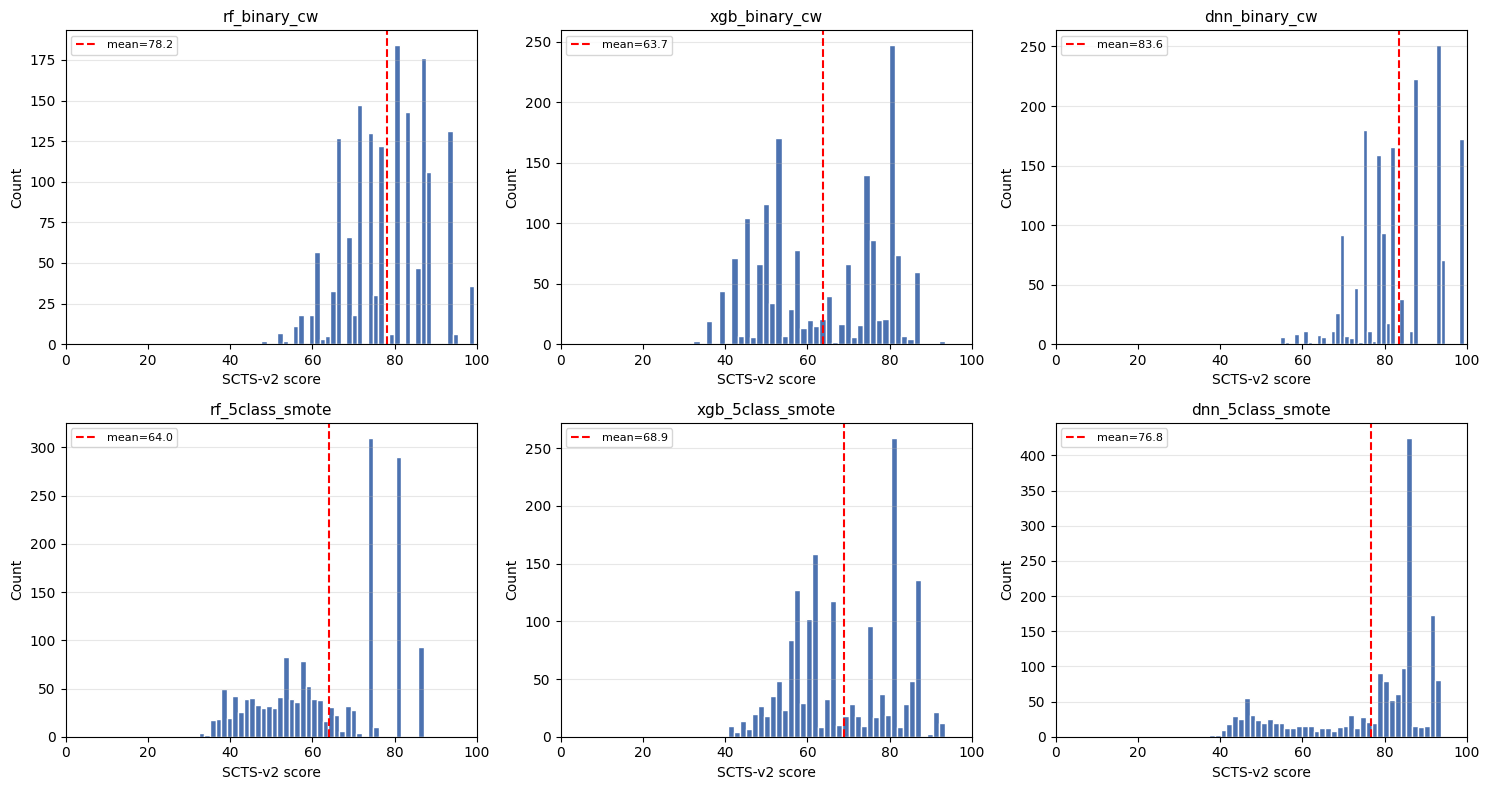

In [12]:
# Distribution of SCTS-v2 per model
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
models_ordered = list(CANONICAL.keys())
for ax, name in zip(axes.flatten(), models_ordered):
    scts = SCTS[name]
    ax.hist(scts, bins=40, color='#4C72B0', edgecolor='white')
    ax.axvline(scts.mean(), color='red', linestyle='--', label=f'mean={scts.mean():.1f}')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('SCTS-v2 score')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nslkdd_scts_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

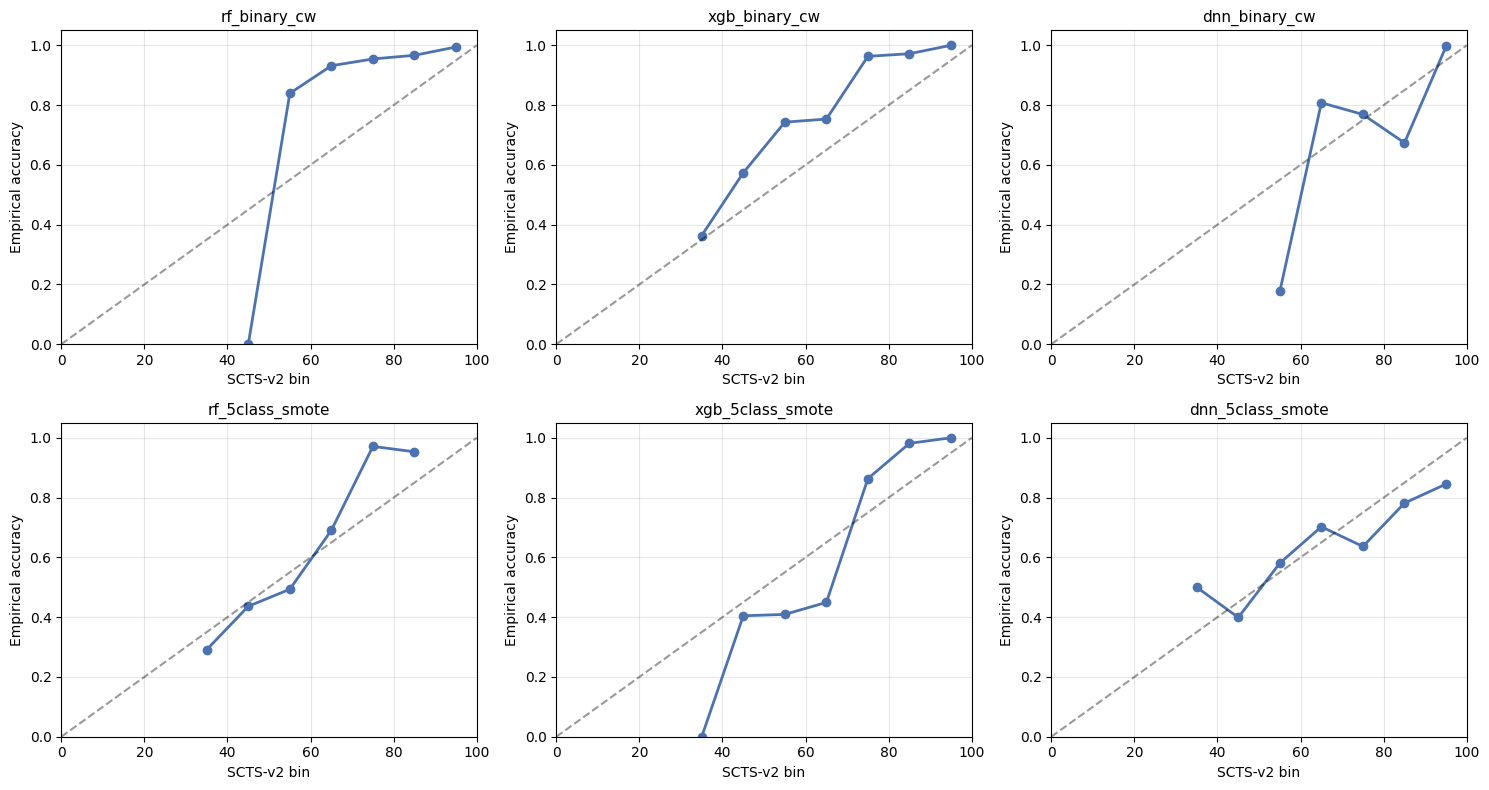

In [13]:
# Reliability: SCTS-v2 vs accuracy (bin samples by SCTS quartile, show empirical accuracy)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.flatten(), models_ordered):
    info = CANONICAL[name]
    y_true = y_stab_b if info['target'] == 'binary' else y_stab_5
    y_pred = get_predictions_stab(name)
    correct = (y_pred == y_true).astype(float)
    scts = SCTS[name]
    # Bin into 10 deciles
    edges = np.linspace(0, 100, 11)
    centres, accs = [], []
    for i in range(10):
        mask = (scts >= edges[i]) & (scts <= edges[i+1])
        if mask.sum() > 0:
            centres.append((edges[i] + edges[i+1]) / 2)
            accs.append(correct[mask].mean())
    ax.plot(centres, accs, 'o-', color='#4C72B0', linewidth=2)
    ax.plot([0, 100], [0, 1], 'k--', alpha=0.4, label='ideal')
    ax.set_xlim(0, 100); ax.set_ylim(0, 1.05)
    ax.set_xlabel('SCTS-v2 bin')
    ax.set_ylabel('Empirical accuracy')
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nslkdd_scts_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 10 — Save and commit

In [14]:
# Save SCTS-v2 arrays per sample (for Notebook 08 LLM alerts)
scts_arrays = {f'{name}': SCTS[name] for name in CANONICAL}
np.savez(SCTS_DIR / 'scts_per_sample.npz', **scts_arrays)

# Save components
components_arrays = {}
for name in CANONICAL:
    components_arrays[f'{name}_c1'] = C1[name]
    components_arrays[f'{name}_c2'] = C2[name]
    components_arrays[f'{name}_c3'] = C3[name]
np.savez(SCTS_DIR / 'components_per_sample.npz', **components_arrays)

# Save conformal metadata
conformal_data = {name: {str(a): v for a, v in CONFORMAL[name].items()} for name in CONFORMAL}
with open(SCTS_DIR / 'conformal_thresholds.json', 'w') as f:
    json.dump(conformal_data, f, indent=2)

print(f'✓ Saved SCTS arrays for {len(CANONICAL)} models')
print(f'  scts_per_sample.npz')
print(f'  components_per_sample.npz')
print(f'  conformal_thresholds.json')

# Commit
os.chdir(REPO)
!git add notebooks/07_scts_v2.ipynb
!git add results/
!git status --short
!git commit -m 'Notebook 07: SCTS-v2 trust score (calibration + stability + conformal)'
!git push

✓ Saved SCTS arrays for 6 models
  scts_per_sample.npz
  components_per_sample.npz
  conformal_thresholds.json
Refresh index: 100% (42/42), done.
 M notebooks/05_stability_tests.ipynb
 M notebooks/06_shap_agreement.ipynb
AM notebooks/07_scts_v2.ipynb
A  results/figures/nslkdd_scts_distributions.png
A  results/figures/nslkdd_scts_reliability.png
A  results/scts/components_per_sample.npz
A  results/scts/conformal_thresholds.json
A  results/scts/scts_per_sample.npz
A  results/tables/nslkdd_scts_alpha_sensitivity.csv
A  results/tables/nslkdd_scts_summary.csv
A  results/tables/nslkdd_scts_validation.csv
?? calibrators/
?? models/
[main 019a867] Notebook 07: SCTS-v2 trust score (calibration + stability + conformal)
 9 files changed, 146 insertions(+)
 create mode 100644 notebooks/07_scts_v2.ipynb
 create mode 100644 results/figures/nslkdd_scts_distributions.png
 create mode 100644 results/figures/nslkdd_scts_reliability.png
 create mode 100644 results/scts/components_per_sample.npz
 create m

In [15]:
import os, shutil, subprocess

REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

# Find Notebook 07 wherever it landed
result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '07_scts_v2.ipynb', '-type', 'f'],
    capture_output=True, text=True
)
print("Notebook 07 found at:")
print(result.stdout if result.stdout else "  Not found")

# Move to notebooks/ if it's somewhere else
nb_target = f'{REPO}/notebooks/07_scts_v2.ipynb'
for line in result.stdout.strip().split('\n'):
    if line and line != nb_target and os.path.exists(line):
        if not os.path.exists(nb_target) or os.path.getmtime(line) > os.path.getmtime(nb_target):
            shutil.move(line, nb_target)
            print(f"✓ Moved to: {nb_target}")
            break

# Check what's already tracked vs untracked
print("\n=== Status ===")
!git status --short

# Add everything that should be tracked
!git add notebooks/07_scts_v2.ipynb
!git add results/
!git commit -m "Notebook 07: SCTS-v2 trust score complete with validation"
!git push

Notebook 07 found at:
/content/drive/MyDrive/XIDS_Research/xids-research/notebooks/07_scts_v2.ipynb


=== Status ===
 M notebooks/05_stability_tests.ipynb
 M notebooks/06_shap_agreement.ipynb
 M notebooks/07_scts_v2.ipynb
?? calibrators/
?? models/
[main 8fb9d60] Notebook 07: SCTS-v2 trust score complete with validation
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/07_scts_v2.ipynb (64%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 170.50 KiB | 4.87 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/anasbiswas1/xids-research.git
   019a867..8fb9d60  main -> main


---
## Summary

**What this notebook produced:**
- ✓ Per-sample SCTS-v2 for all 6 canonical models (1,633 samples each)
- ✓ Three components saved separately (c₁ calibration, c₂ stability, c₃ conformal)
- ✓ Conformal thresholds at three α levels (0.05, 0.10, 0.20)
- ✓ Per-class summary table
- ✓ α sensitivity analysis
- ✓ Validation: correlation between SCTS-v2 and correctness
- ✓ SCTS distribution + reliability diagrams

**Healthy patterns to look for:**
- Mean SCTS-v2 should be in the 40-80 range. If everything is ~95, SCTS isn't discriminating. If everything is ~10, calibration/stability are too pessimistic.
- Positive Pearson correlation between SCTS and correctness (should be 0.15-0.40). Higher means SCTS is a useful signal for an analyst.
- Empirical accuracy in the top SCTS quartile should be higher than in the bottom quartile. If not, SCTS isn't working.
- α sensitivity: changing α from 0.05 to 0.20 should change mean SCTS by 5-15 points, not 0 or 50.

**Next notebook (08):** LLM alert layer. GPT-4o + Llama-3-8B generate plain-English alerts conditioned on top-SHAP features and SCTS-v2 score. Rule-based recommender outputs action (block/escalate/enrich/ignore).
